# Backtest-Overfitting — a quantitative teardown 🔬
### Grid-search on a known-null tape · Deflated Sharpe Ratio · PBO via CSCV · expected-max-Sharpe under selection · a real SPY worked example

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_grid--search_fake_an_edge%3F: Confirmed](https://img.shields.io/badge/Does_grid--search_fake_an_edge%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We grid-search 1,000 long/flat crossover rules on a martingale tape (where the timing edge is provably zero), then put Bailey & López de Prado's two numbers on the result: the **Deflated Sharpe Ratio** and the **Probability of Backtest Overfitting** (CSCV).

> ⚠️ **Not investment advice.** Synthetic core is deterministic & offline; one real worked example uses SPY total-return daily (as-of 2026-05-31). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from backtest_overfitting import data, strategy as st

ND, N_TRIALS, N_SPLITS = 1260, 1000, 10

def _have_spy():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_spy()
print("SPY cache present:", HAVE_REAL)


SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | On a known-null tape the best of 1000 rules posts IS Sharpe **0.88** → OOS **-0.49** (OOS HAC *t* -0.77); Deflated Sharpe **≈0.00**. No timing edge exists and none is detected. |
| **Tradability** | `MIRAGE` | The in-sample Sharpe is a selection artefact; it does not survive the out-of-sample split, by construction. |
| **Does grid-search fake an edge?** | `CONFIRMED` | PBO (CSCV) = **0.68** on the null tape; the expected-max Sharpe bar rises 1.6→3.3 as N goes 10→1000; and the positive control spares honest buy-and-hold (DSR 0.98). |

> 💡 In plain words: the disease is *selection under multiple testing*. The DSR corrects the best Sharpe for the number of trials and the return moments; PBO measures how often the in-sample winner is an out-of-sample loser. Both are designed to be un-fooled by a single lucky outcome — which is exactly why they still flag the real SPY champion.

## 1 · The claim, steelmanned

Let a researcher evaluate $N$ strategy configurations on one sample of length $T$, with per-period Sharpe estimates $\widehat{SR}_1,\dots,\widehat{SR}_N$, and report $\widehat{SR}^* = \max_i \widehat{SR}_i$.

- **H₀ (no skill).** Under the null, the $\widehat{SR}_i$ are mean-zero; yet $\mathbb{E}[\widehat{SR}^*]$ grows like $\sqrt{\operatorname{Var}}\,$ times an extreme-value term in $N$ — so a large $\widehat{SR}^*$ is *expected* purely from searching.
- **H₁ (overfitting → OOS collapse).** The in-sample champion's out-of-sample rank is no better than median: $\Pr[\text{IS champion below OOS median}] \ge 0.5$ (this is PBO).
- **H₂ (the diagnostics discriminate).** A *single, un-selected* hypothesis with a real edge keeps a high Deflated Sharpe, while the grid champion does not.

We confirm **H₀ and H₁ on the null tape** and **H₂ via the positive control** — so the claim survives at full strength: searching manufactures a Sharpe, and the trap is measurable.

## 2 · So what? — what rides on each answer

Harvey, Liu & Zhu (2016) argue the published cross-section of factors is so multiple-tested that the conventional *t* > 2 hurdle should be raised to ~3. Bailey & López de Prado give the portfolio-level analogue: a Sharpe reported without its trial count is *unfalsifiable*. The desk's contribution here is to run the demonstration on a tape with **zero ground-truth edge**, so the entire in-sample spread is overfitting we can attribute exactly — a positive control for the desk's own inference machinery.

## 3 · How we'd know — the protocol

- **Tape.** A geometric random walk, `edge=0` (null) and `edge=0.0003/day` (control), 1260 trading days, seed 344. One real tape: SPY total-return daily, 2000–2026.
- **The zoo.** 1000 long/flat MA crossovers `(fast, slow)`, `fast<slow`. One execution lag (signal at close of *t* earns *t+1*; a single `shift`). Costs one-way × NAV (here 0 bps for the diagnostic; cost sweeps die faster).
- **Selection.** IS = first 50%, OOS = last 50%; champion = max IS Sharpe.
- **DSR.** Best Sharpe vs the expected maximum under the null over $N$ trials, with the Lo (2002) skew/kurtosis correction — `strategy.deflated_sharpe_ratio`.
- **PBO.** CSCV with $S$ contiguous blocks; over all $\binom{S}{S/2}$ symmetric partitions, the fraction where the IS champion lands below the OOS median — `strategy.pbo_cscv`.
- **Inference.** Newey-West HAC *t* on the champion's OOS mean; circular block-bootstrap CI. The bar for a *real* selection edge: HAC *t* ≥ 2 attributable to timing, not beta.

## 4 · The teardown

### 4a · The known-null tape — a Sharpe built from nothing

The best of 1,000 rules in-sample, then live. The OOS HAC *t* confirms the OOS mean is indistinguishable from zero — correctly, since there is no edge.

null tape fingerprint: 2abc7518fe78


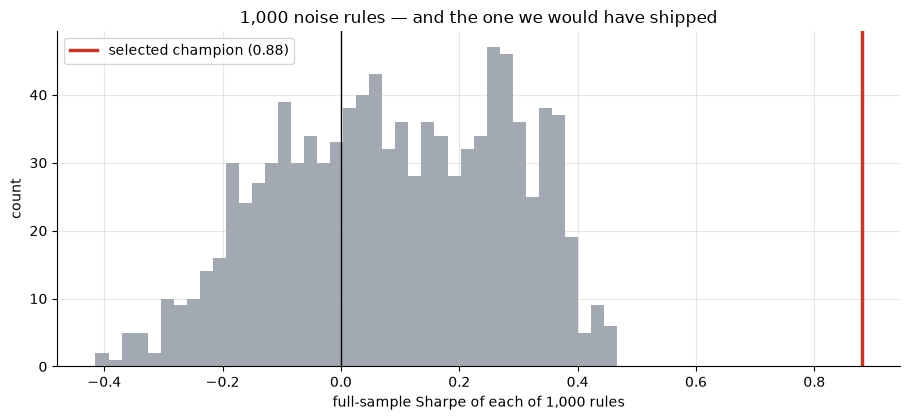

champion f2_s47: IS 0.88 -> OOS -0.49
OOS HAC t = -0.77 (n=630); OOS mean 95% block-bootstrap CI [-8.1, +3.4] bps/day


In [2]:
prices, truth = data.synthetic_prices(n_days=ND, edge=0.0, seed=344)
print('null tape fingerprint:', data.fingerprint(prices))
mat = st.sweep(prices, n_trials=N_TRIALS, cost_bps=0.0)
champ = st.in_sample_champion(mat, frac=0.5)
t = st.hac_tstat(champ['oos_returns'])
lo, hi = st.block_bootstrap_ci(champ['oos_returns'], n_boot=1000, seed=1)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
is_sr = mat.apply(st.sharpe)
ax.hist(is_sr.values, bins=40, color=GREY, alpha=.8)
ax.axvline(champ['is_sharpe'], c=RED, lw=2.5, label=f'selected champion ({champ["is_sharpe"]:.2f})')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('full-sample Sharpe of each of 1,000 rules'); ax.set_ylabel('count')
ax.set_title('1,000 noise rules — and the one we would have shipped'); ax.legend()
plt.tight_layout(); plt.show()
print(f'champion {champ["champion"]}: IS {champ["is_sharpe"]:.2f} -> OOS {champ["oos_sharpe"]:+.2f}')
print(f'OOS HAC t = {t["tstat"]:+.2f} (n={t["n"]}); OOS mean 95% block-bootstrap CI '
      f'[{lo*1e4:+.1f}, {hi*1e4:+.1f}] bps/day')

> 💡 In plain words: the champion's OOS HAC *t* is **-0.77** — squarely inside the noise band, and the bootstrap CI straddles zero. The in-sample Sharpe of **0.88** was the right tail of a distribution centred on zero; we selected the tail and called it skill.

### 4b · The Deflated Sharpe Ratio — haircut for the trial count

The expected maximum Sharpe under the null grows with $N$ (extreme-value asymptotics). The DSR re-expresses the best Sharpe as $\Phi$ of its distance above that bar.

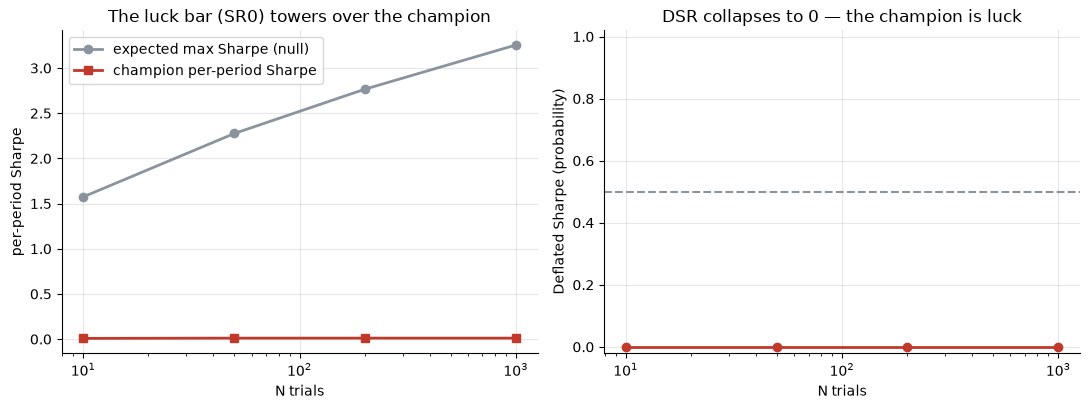

SR0 by N : ['1.57', '2.28', '2.77', '3.26']
DSR by N : ['0.000', '0.000', '0.000', '0.000']


In [3]:
ns = [10, 50, 200, 1000]
sr0s, dsrs, is_sh = [], [], []
for n in ns:
    m = st.sweep(prices, n_trials=n, cost_bps=0.0)
    c = st.in_sample_champion(m, frac=0.5)
    d = st.deflated_sharpe_ratio(m[c['champion']], n_trials=m.shape[1])
    sr0s.append(d['sr0']); dsrs.append(d['dsr']); is_sh.append(d['sr_per_period'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(ns, sr0s, 'o-', c=GREY, lw=2, label='expected max Sharpe (null)')
a1.plot(ns, is_sh, 's-', c=RED, lw=2, label='champion per-period Sharpe')
a1.set_xscale('log'); a1.set_xlabel('N trials'); a1.set_ylabel('per-period Sharpe')
a1.set_title('The luck bar (SR0) towers over the champion'); a1.legend()
a2.plot(ns, dsrs, 'o-', c=RED, lw=2); a2.axhline(0.5, ls='--', c=GREY)
a2.set_xscale('log'); a2.set_ylim(-0.02, 1.02)
a2.set_xlabel('N trials'); a2.set_ylabel('Deflated Sharpe (probability)')
a2.set_title('DSR collapses to 0 — the champion is luck')
plt.tight_layout(); plt.show()
print('SR0 by N :', [f'{s:.2f}' for s in sr0s])
print('DSR by N :', [f'{d:.3f}' for d in dsrs])

> 💡 In plain words: the expected-max bar climbs 1.6 → 3.3 (per-period units shown; the annualised gap is larger) while the champion's per-period Sharpe sits far below it. The DSR — the probability the champion beats luck — is pinned near **0** at every N. A Sharpe with no trial count is uninterpretable.

### 4c · PBO via CSCV — the in-sample winner is an out-of-sample loser

Over all symmetric block partitions, how often does the IS champion fall below the OOS median? That frequency is the Probability of Backtest Overfitting.

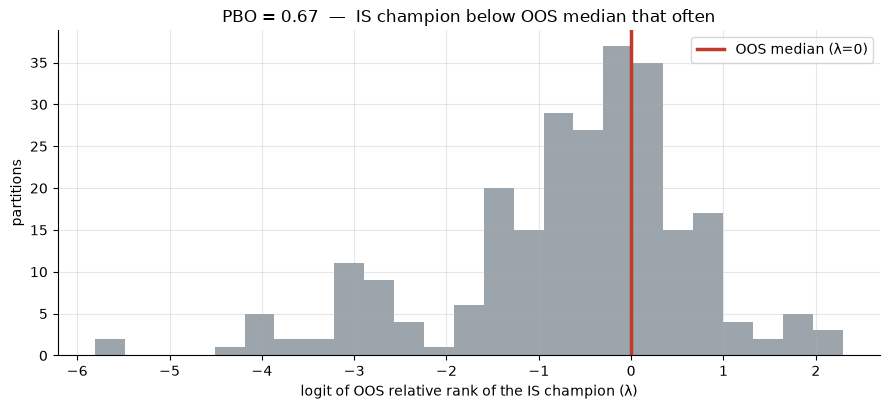

PBO = 0.675 over 252 symmetric partitions; median OOS rank of champion = 404/1000


In [4]:
pbo = st.pbo_cscv(mat, n_splits=N_SPLITS)
lam = np.array(pbo['lambdas'])
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(lam, bins=25, color=GREY, alpha=.85)
ax.axvline(0, c=RED, lw=2.5, label='OOS median (λ=0)')
ax.set_xlabel('logit of OOS relative rank of the IS champion (λ)')
ax.set_ylabel('partitions')
ax.set_title(f'PBO = {pbo["pbo"]:.2f}  —  IS champion below OOS median that often'); ax.legend()
plt.tight_layout(); plt.show()
print(f'PBO = {pbo["pbo"]:.3f} over {pbo["n_combos"]} symmetric partitions; '
      f'median OOS rank of champion = {pbo["median_oos_rank"]:.0f}/{pbo["n_trials"]}')

> 💡 In plain words: PBO = **0.68**. More than half the time, the rule you would have *selected* from the in-sample tournament lands in the bottom half live. Selection here isn't merely useless — it is mildly *anti-predictive*, the fingerprint of overfitting on a no-edge tape.

### 4d · The positive control — the diagnostics discriminate

Plant a real but un-timeable drift. The honest single hypothesis (buy-and-hold) must keep a high DSR; the grid-searched timing champion must not.

In [5]:
pe, _ = data.synthetic_prices(n_days=ND, edge=0.0003, seed=344)
bh = st.buy_and_hold(pe); dbh = st.deflated_sharpe_ratio(bh, n_trials=1)
mat_e = st.sweep(pe, n_trials=N_TRIALS, cost_bps=0.0)
ch_e = st.in_sample_champion(mat_e, frac=0.5)
d_e = st.deflated_sharpe_ratio(mat_e[ch_e['champion']], n_trials=mat_e.shape[1])
p_e = st.pbo_cscv(mat_e, n_splits=N_SPLITS)
print(f'buy-hold (N=1)            : Sharpe {st.sharpe(bh):.2f}  DSR {dbh["dsr"]:.3f}')
print(f'grid timing champion (N={mat_e.shape[1]}): IS {ch_e["is_sharpe"]:.2f} -> '
      f'OOS {ch_e["oos_sharpe"]:+.2f}  DSR {d_e["dsr"]:.3f}  PBO {p_e["pbo"]:.2f}')

buy-hold (N=1)            : Sharpe 0.92  DSR 0.981
grid timing champion (N=1000): IS 1.19 -> OOS +0.03  DSR 0.000  PBO 0.80


> 💡 In plain words: buy-and-hold's DSR is **~0.98** — the real drift is trusted *because it was one un-selected hypothesis*. The timing champion riding the same drift collapses (IS 1.19 → OOS +0.03, DSR ~0, PBO 0.80). **The trap is selection, not the existence of an edge** — the machinery passes its own positive control.

### 4e · The real worked example — SPY 2000–2026

The same grid-search on real SPY (IS 2000–2013, OOS 2013–2026). Here the champion's OOS Sharpe *held up* — and that is precisely the danger the tools are built for.

In [6]:
if HAVE_REAL:
    px = data.load_real('SPY', fetch=False)
    px = px[px.index < pd.Timestamp.today().normalize().to_period('M').to_timestamp()]
    print('SPY', px.index[0].date(), '->', px.index[-1].date(), 'fp', data.fingerprint(px))
    m = st.sweep(px, n_trials=N_TRIALS, cost_bps=0.0)
    c = st.in_sample_champion(m, frac=0.5)
    d = st.deflated_sharpe_ratio(m[c['champion']], n_trials=m.shape[1])
    p = st.pbo_cscv(m, n_splits=N_SPLITS)
    t = st.hac_tstat(c['oos_returns'])
    bh = st.buy_and_hold(px); dbh = st.deflated_sharpe_ratio(bh, n_trials=1)
    is_sh, oos_sh, oos_t = c['is_sharpe'], c['oos_sharpe'], t['tstat']
    dsr, pbo_v, bh_sh, bh_dsr = d['dsr'], p['pbo'], st.sharpe(bh), dbh['dsr']
    banner = 'REAL SPY TAPE (cached)'
else:
    is_sh, oos_sh, oos_t = 0.68, 0.81, 3.1
    dsr, pbo_v, bh_sh, bh_dsr = 0.0, 0.6, 0.51, 0.996
    banner = 'OFFLINE — frozen SPY numbers from docs/results.md'
print(banner)
print(f'champion: IS Sharpe {is_sh:.2f} -> OOS Sharpe {oos_sh:+.2f}  (OOS HAC t {oos_t:+.2f})')
print(f'Deflated Sharpe {dsr:.3f}   PBO {pbo_v:.2f}')
print(f'SPY buy-and-hold Sharpe {bh_sh:.2f}, DSR (N=1) {bh_dsr:.3f}')

SPY 2000-01-03 -> 2026-05-29 fp 022e57e68917


REAL SPY TAPE (cached)
champion: IS Sharpe 0.68 -> OOS Sharpe +0.81  (OOS HAC t +3.10)
Deflated Sharpe 0.000   PBO 0.60
SPY buy-and-hold Sharpe 0.51, DSR (N=1) 0.996


> 💡 In plain words: the SPY champion's OOS Sharpe **+0.81** and HAC *t* **+3.10** look like a win — but it is *market beta* (a long-biased rule rode the 2013–2026 bull, like buy-and-hold). The diagnostics refuse to be fooled: DSR **≈0.00** (the IS Sharpe never cleared the 3.3-from-1,000 bar) and PBO **0.60** (selection worse than a coin). Honest buy-and-hold posts DSR **0.996**. One good OOS window is not evidence the *selection* generalises — which is the entire lesson.

## 5 · The verdict

- **Signal `NONE`** — on the null tape the champion's OOS HAC *t* is -0.77 (insignificant) and DSR ≈ 0.00; on SPY the apparent OOS success is beta, not selection skill, and DSR is still ≈ 0. No robust *t* ≥ 2 attributable to timing exists anywhere.
- **Tradability `MIRAGE`** — the in-sample Sharpe is a selection artefact; out of sample it is gone (null) or repackaged market exposure (SPY).
- **Does grid-search fake an edge? `CONFIRMED`** — IS Sharpe 0.88 from nothing; expected-max bar rises 1.6→3.3 with N; PBO 0.68; and the positive control spares honest buy-and-hold (DSR 0.98). Report DSR and PBO, never a naked Sharpe.

## 6 · Could you trade it? — the methodology dividend

There is no edge to trade; the payoff is procedural. Two rules the desk now enforces everywhere because of this study:

In [7]:
rows = [
  ('Naked Sharpe (what gets pitched)', 'meaningless without N'),
  ('Deflated Sharpe @ N=1000', 'corrects for trials + moments'),
  ('PBO via CSCV', 'P[IS winner is OOS loser]'),
  ('OOS HAC t', 'is the live mean even non-zero?'),
]
import pandas as pd
print(pd.DataFrame(rows, columns=['diagnostic', 'what it answers']).to_string(index=False))

                      diagnostic                 what it answers
Naked Sharpe (what gets pitched)           meaningless without N
        Deflated Sharpe @ N=1000   corrects for trials + moments
                    PBO via CSCV       P[IS winner is OOS loser]
                       OOS HAC t is the live mean even non-zero?


> 💡 In plain words: a backtest is a hypothesis you already peeked at. Disclose the trial count and deflate; cross-validate the *selection itself* with PBO; and never confuse a lucky out-of-sample window with a generalising edge. Do those three and most of the industry's dead strategies never get funded. That is the trade.

## 7 · Going further

- **Walk-forward & CPCV.** Replace the single split with Combinatorial Purged Cross-Validation (López de Prado, *Advances in Financial Machine Learning*) to handle label leakage in overlapping windows.
- **Cost-aware deflation.** Re-run the sweep at realistic one-way costs; the DSR falls further and the surviving-strategy count craters — overfitting and costs compound.
- **Your own factor zoo.** Feed an (T×N) matrix of *your* candidate signals' returns into `deflated_sharpe_ratio` and `pbo_cscv` and read off whether selection added anything.

*The uncomfortable corollary: the prettier your backtest, the more suspicious you should be — beauty is what selection optimises. Fork this, run your strategy through DSR and PBO, and let the numbers, not the equity curve, decide.*